## Lake Zug APhys-AChem Meeting (11.5.2026)

In [1]:
# imports
import ewgreaders as ewg
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
lake = 'Zug'
year = '2026'
date = '20260409'

In [3]:
def load_oxygen_logger_chain(lake, year, date, loc):
    mreader = ewg.mooring_reader.MooringReader(lake, year, date, loc)
    t_start = mreader.deploy + pd.Timedelta(days=1)
    t_end = mreader.retrieve - pd.Timedelta(days=1)
    oxygen_loggers = mreader.get_oxygen_loggers()

    all_ds = []
    for ol in oxygen_loggers:
        try:
            oreader = ewg.o2_reader.O2Reader(lake, year, date, loc, ol['serial_id'])
            ds = oreader.load()
            ds = ds.sel(time=slice(t_start, t_end))
            
            # anoxic region
            if ds['depth'] > 100:
                ds['do2_conc'] = ds['do2_conc'] - ds['do2_conc'].min()
            
            all_ds.append(ds)
        except FileNotFoundError:
            continue

    ds_do = mreader.create_instrument_chain(all_ds)

    return ds_do

def load_adcp(lake, year, date, loc, i=0):
    mreader = ewg.mooring_reader.MooringReader(lake, year, date, loc)
    t_start = mreader.deploy + pd.Timedelta(days=1)
    t_end = mreader.retrieve - pd.Timedelta(days=1)
    adcp = mreader.get_adcps()[i]

    areader = ewg.adcp_reader.ADCPReader(lake, year, date, loc, adcp['serial_id'])
    ds = areader.load()
    ds = ds.sel(time=slice(t_start, t_end))

    return ds

In [4]:
ds_do_w = load_oxygen_logger_chain(lake, year, date, 'LZW')
ds_do_c = load_oxygen_logger_chain(lake, year, date, 'LZC')
ds_do_e = load_oxygen_logger_chain(lake, year, date, 'LZE')

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:231: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')
C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:231: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_alig

In [5]:
ds_adcp_w = load_adcp(lake, year, date, 'LZW')
ds_adcp_c = load_adcp(lake, year, date, 'LZC', -1)
ds_adcp_e = load_adcp(lake, year, date, 'LZE')

### Oxygen Heatmaps

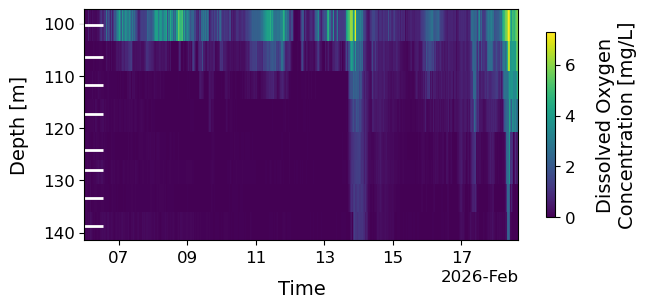

In [84]:
deploy = pd.to_datetime('2026-02-05')
retrieve = pd.to_datetime('2026-04-09')
t_start = deploy + pd.Timedelta(days=1)
#t_end = retrieve - pd.Timedelta(days=1)
t_end = ds_adcp_e.time.values[-1]

fig, ax = plt.subplots(figsize=(7, 3))

im = ds_do_w.do2_conc.sel(time=slice(t_start, t_end)).plot(x='time', y='depth', cmap='viridis', vmin=0, ax=ax, cbar_kwargs={'shrink': 0.8}, rasterized=True)
im.colorbar.ax.tick_params(labelsize=12)
im.colorbar.ax.set_ylabel('Dissolved Oxygen\nConcentration [mg/L]', fontsize=14, labelpad=15)
ax.xaxis.get_offset_text().set_fontsize(12)

# oxygen loggers
for d in ds_do_w.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)   

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.invert_yaxis()
plt.savefig('../gallery/zug_aphys_achem/2026_05_11/o2_ts.svg', bbox_inches='tight')
plt.show()

### Flow direction and deep oxygen

In [112]:
def plot_vel_o2(uw, vw, ds_o2_sel, t0, tf, ttl, gallery_file):
    fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(9, 7), sharex=True, sharey=True)

    # along shore velocity
    pcv = vw.sel(time=slice(t0, tf)).plot(x='time', y='depth', cmap='RdBu_r', vmin=-0.1, vmax=0.1, ax=ax[0], cbar_kwargs={'shrink': 0.8}, rasterized=True)
    pcv.colorbar.ax.tick_params(labelsize=12)
    pcv.colorbar.ax.set_ylabel('Velocity [m/s]', fontsize=12, labelpad=10)

    # cross shore velocity
    pcu = uw.sel(time=slice(t0, tf)).plot(x='time', y='depth', cmap='RdBu_r', vmin=-0.1, vmax=0.1, ax=ax[1], cbar_kwargs={'shrink': 0.8}, rasterized=True)
    pcu.colorbar.ax.tick_params(labelsize=12)
    pcu.colorbar.ax.set_ylabel('Velocity [m/s]', fontsize=12, labelpad=10)

    # oxygen
    im = ds_o2_sel.sel(time=slice(t0, tf)).do2_conc.plot(cmap='viridis', vmin=0, ax=ax[2], cbar_kwargs={'shrink': 0.8}, rasterized=True)
    im.colorbar.ax.tick_params(labelsize=12)
    im.colorbar.ax.set_ylabel('Dissolved Oxygen\nConcentration [mg/L]', fontsize=12, labelpad=15)
    ax[2].xaxis.get_offset_text().set_fontsize(12)

    # oxygen loggers
    for d in ds_o2_sel.depth:
        ax[0].plot(0.01, d.item(), marker='_', markersize=18, markeredgewidth=2, color='black', transform=ax[0].get_yaxis_transform(), clip_on=False)
        ax[1].plot(0.01, d.item(), marker='_', markersize=18, markeredgewidth=2, color='black', transform=ax[1].get_yaxis_transform(), clip_on=False)
        ax[2].plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax[2].get_yaxis_transform(), clip_on=False)        

    ax[0].set_xlabel('')
    ax[1].set_xlabel('')
    ax[2].set_xlabel('Time', fontsize=14, labelpad=10)
    ax[0].set_title('Along Shore [N-S]', fontsize=12)
    ax[1].set_title('Cross Shore [E-W]', fontsize=12)

    for i in range(len(ax)):
        ax[i].set_ylabel('')
        ax[i].tick_params(axis='both', labelsize=12)
        ax[i].invert_yaxis()

    fig.supylabel('Depth [m]', fontsize=14)
    fig.suptitle(ttl, fontsize=14, x=0.45, y=1)

    plt.tight_layout()
    plt.savefig(f'../gallery/zug_aphys_achem/2026_05_11/{gallery_file}.svg', bbox_inches='tight')
    plt.show()

In [86]:
# LZW
uw = ds_adcp_w.vel.sel(dir='E')
vw = ds_adcp_w.vel.sel(dir='N')
ds_dow_sel = ds_do_w.sel(depth=slice(ds_adcp_w.depth.min(), ds_adcp_w.depth.max()))

# LZC
uc = ds_adcp_c.vel.sel(dir='E')
vc = ds_adcp_c.vel.sel(dir='N')
ds_doc_sel = ds_do_c.sel(depth=slice(ds_adcp_c.depth.min(), ds_adcp_c.depth.max()))

# LZE
ue = ds_adcp_e.vel.sel(dir='E')
ve = ds_adcp_e.vel.sel(dir='N')
ds_doe_sel = ds_do_e.sel(depth=slice(ds_adcp_e.depth.min(), ds_adcp_e.depth.max()))

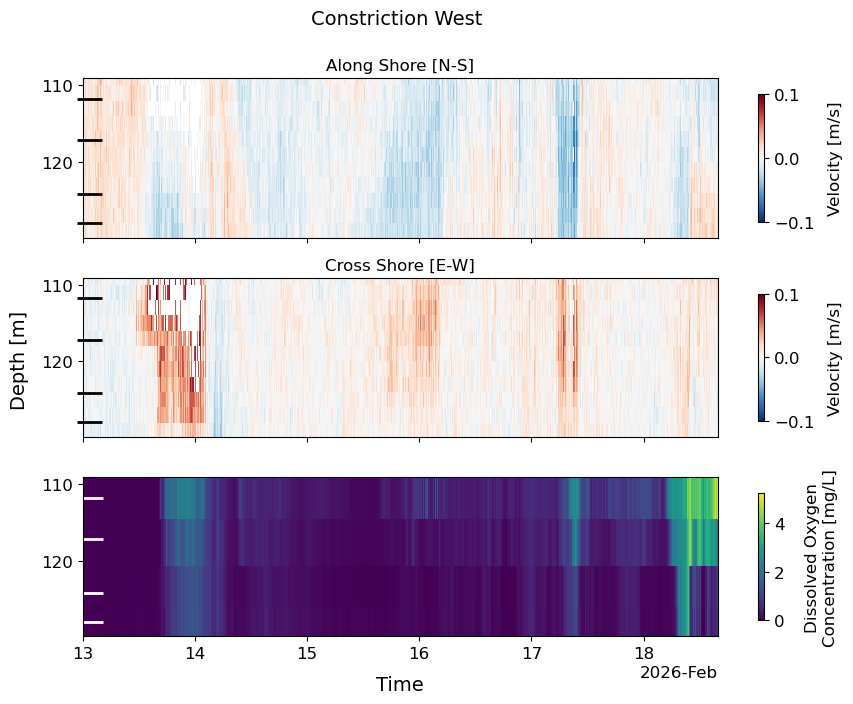

In [113]:
t0 = '2026-02-13'
tf = pd.to_datetime(t0) + pd.Timedelta(days=7)

plot_vel_o2(uw, vw, ds_dow_sel, t0, t_end, 'Constriction West', 'flow_dir_w')

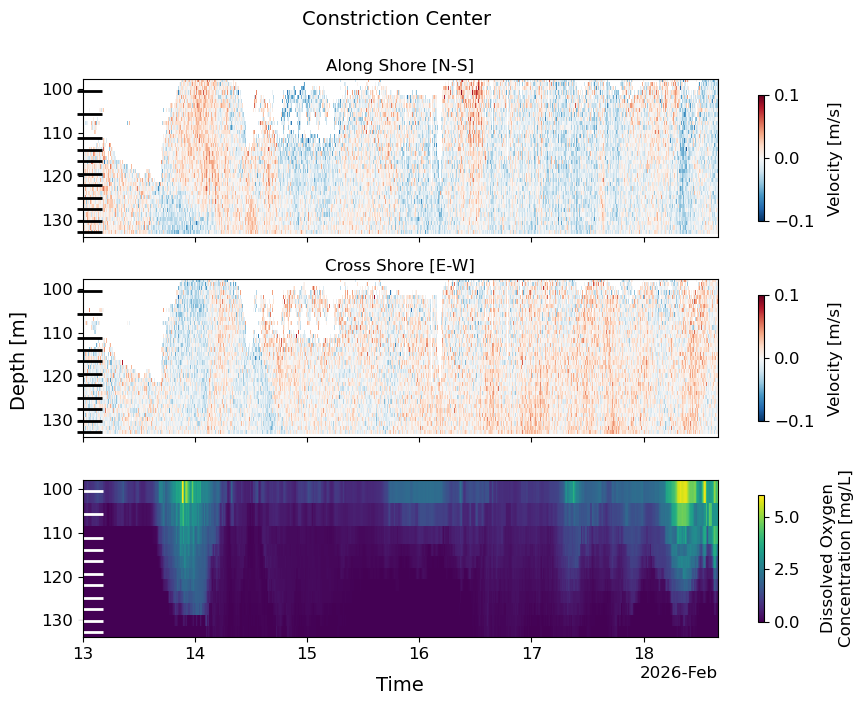

In [114]:
t0 = '2026-02-13'
tf = pd.to_datetime(t0) + pd.Timedelta(days=7)

plot_vel_o2(uc, vc, ds_doc_sel, t0, t_end, 'Constriction Center', 'flow_dir_c')

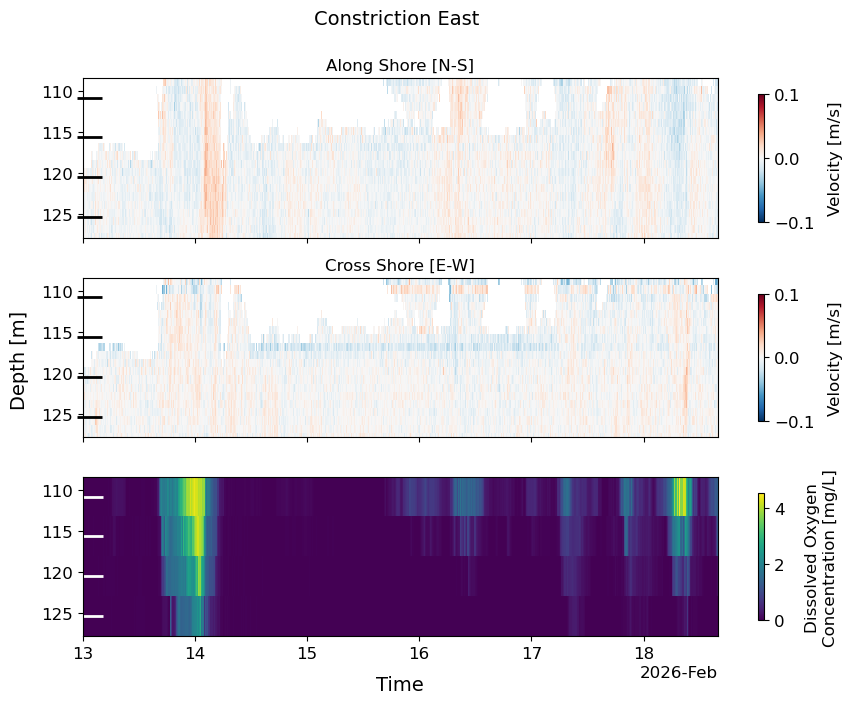

In [115]:
t0 = '2026-02-13'
tf = pd.to_datetime(t0) + pd.Timedelta(days=7)

plot_vel_o2(ue, ve, ds_doe_sel, t0, t_end, 'Constriction East', 'flow_dir_e')

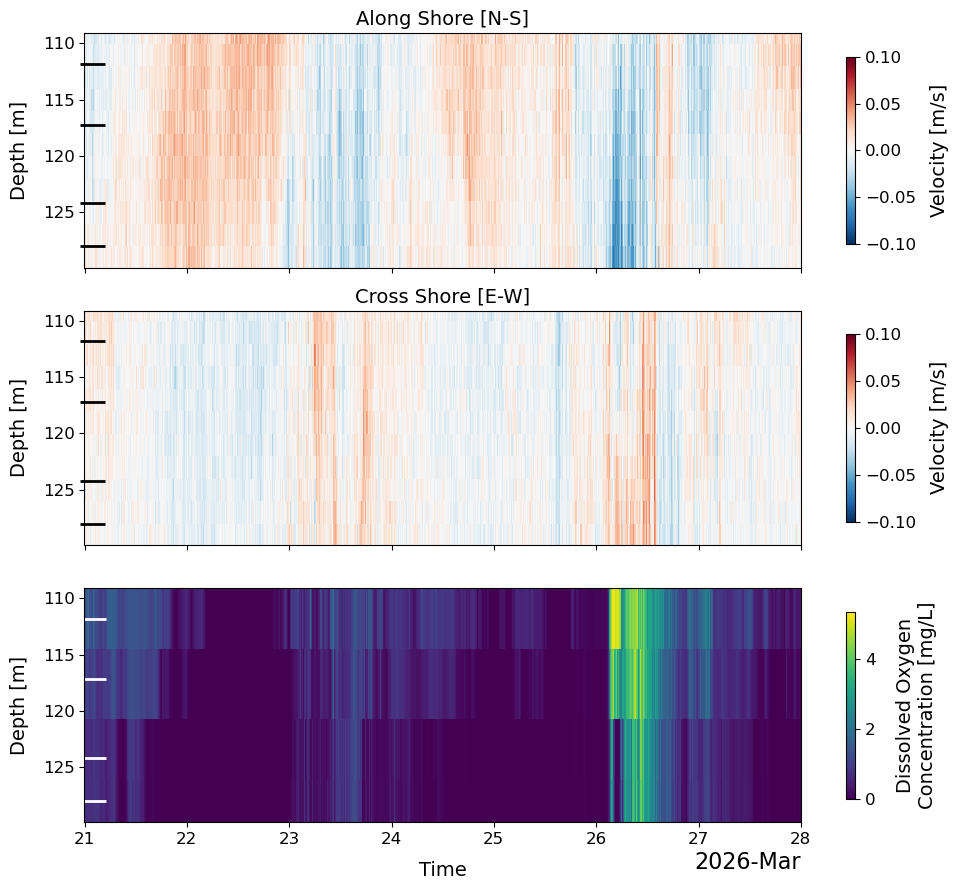

In [11]:
t0 = '2026-03-21'
tf = pd.to_datetime(t0) + pd.Timedelta(days=7)

plot_vel_o2(uw, vw, ds_dow_sel, t0, tf)

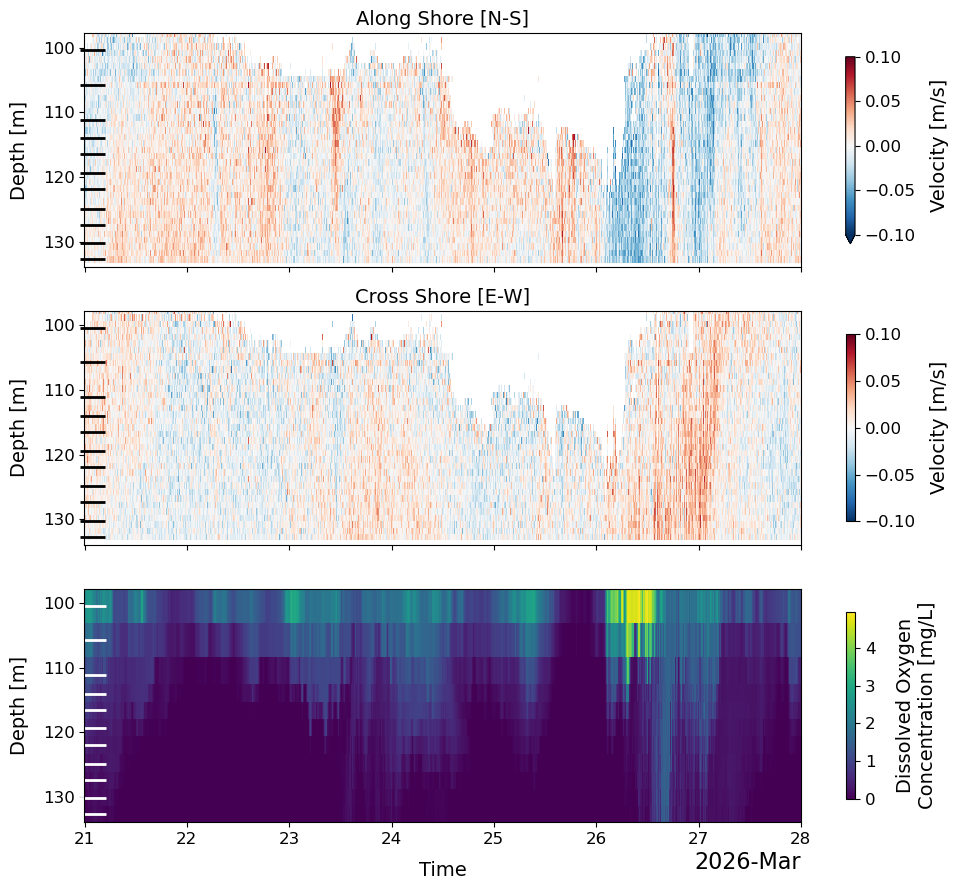

In [12]:
t0 = '2026-03-21'
tf = pd.to_datetime(t0) + pd.Timedelta(days=7)

plot_vel_o2(uc, vc, ds_doc_sel, t0, tf)

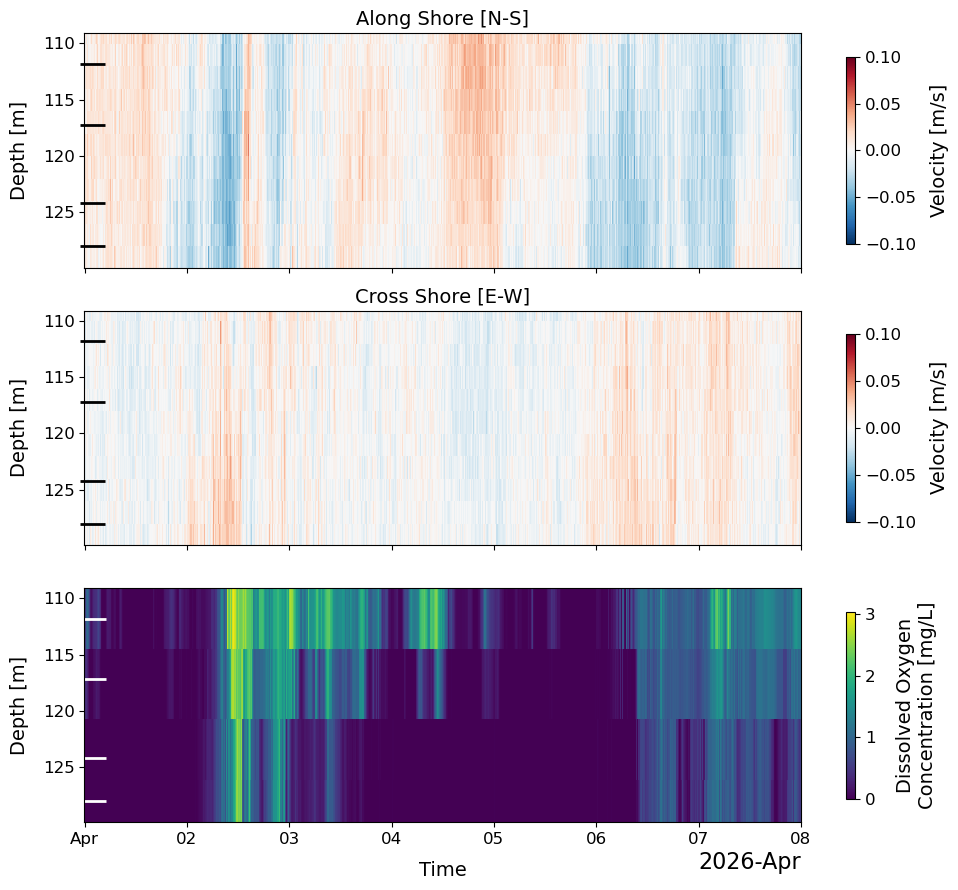

In [13]:
t0 = '2026-04-01'
tf = pd.to_datetime(t0) + pd.Timedelta(days=7)

plot_vel_o2(uw, vw, ds_dow_sel, t0, tf)

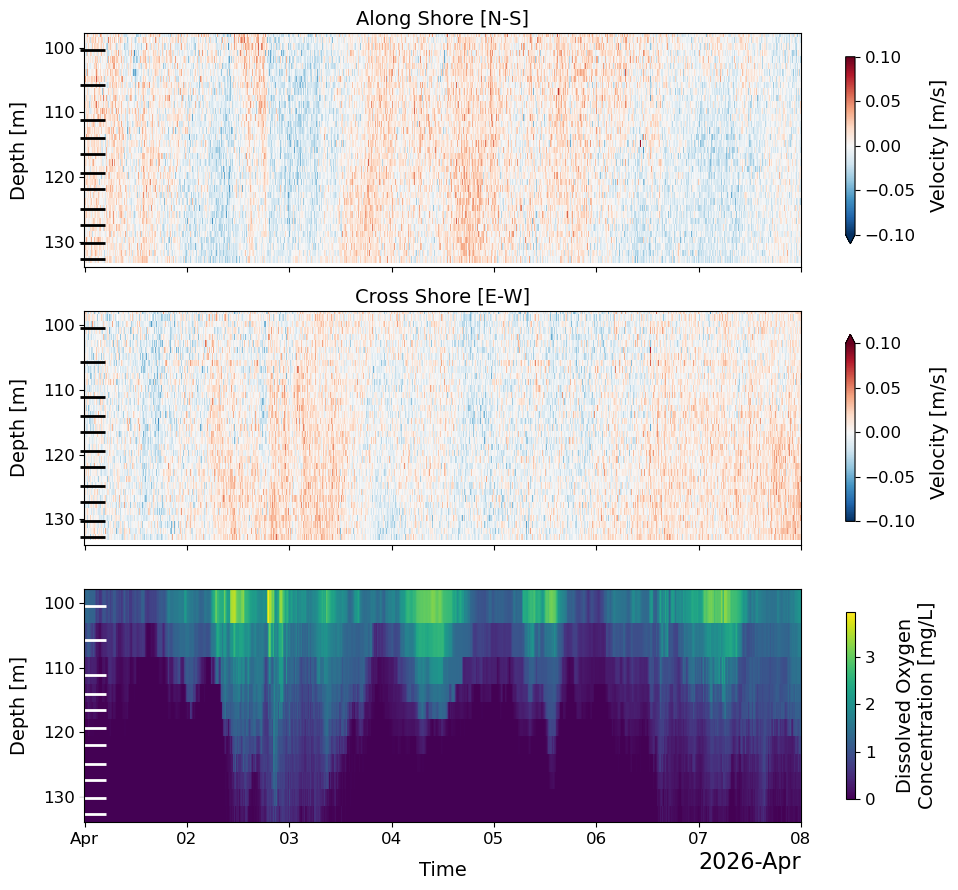

In [14]:
t0 = '2026-04-01'
tf = pd.to_datetime(t0) + pd.Timedelta(days=7)

plot_vel_o2(uc, vc, ds_doc_sel, t0, tf)

### Flow speed & deep oxygen

Horizontal flow speed timeseries and oxgyen concentration.

In [116]:
# horizontal flow speed
speed_w = np.sqrt(uw**2 + vw**2).mean(dim='depth')

# oxygen concentration
do_w = ds_o2_sel.do2_conc.sum(dim='depth')

# 1-hour rolling average
window = 6
sw_ra = speed_w.rolling(time=window, center=True).mean()
dow_ra = do_w.rolling(time=window*10, center=True).mean()

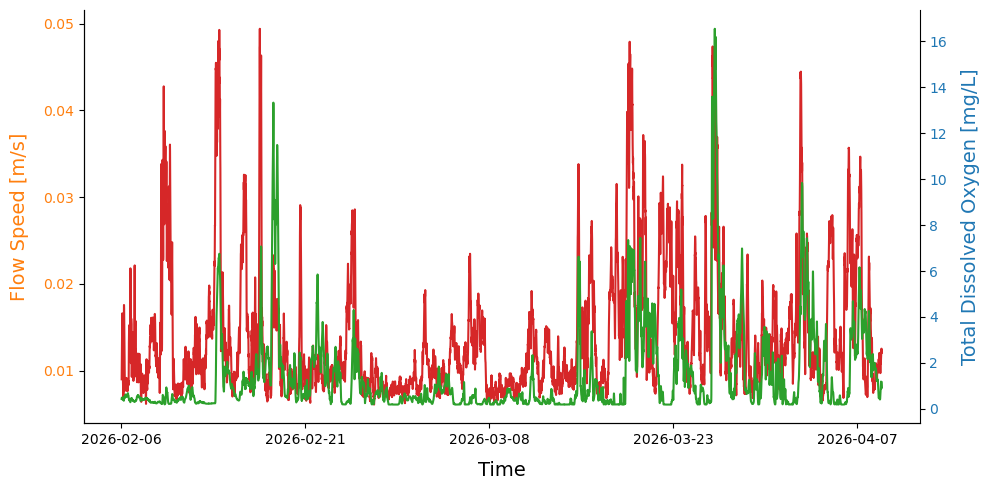

In [117]:
# Create the figure and the primary axes
fig, ax1 = plt.subplots(figsize=(10, 5))

# 1. Plot the first variable (Speed) on the left axis
sns.lineplot(x=sw_ra.time, y=sw_ra, color='tab:red', ax=ax1)

# Set left y-axis label and color
ax1.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10, color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:orange')

# 2. Create a twin axes for the second variable (DO)
ax2 = ax1.twinx()

# Plot the second variable on the right axis
sns.lineplot(x=dow_ra.time, y=dow_ra, color='tab:green', ax=ax2)

# Set right y-axis label and color
ax2.set_ylabel('Total Dissolved Oxygen [mg/L]', fontsize=14, labelpad=10, color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# 3. Formatting cleanup
ax1.set_xlabel('Time', fontsize=14, labelpad=10)
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=15))

# Remove top spines for both, but keep right spine for ax2
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False) # This hides the "border" of ax1, not ax2

plt.tight_layout()
plt.show()

### Spatial variability of deep oxygen in constriction

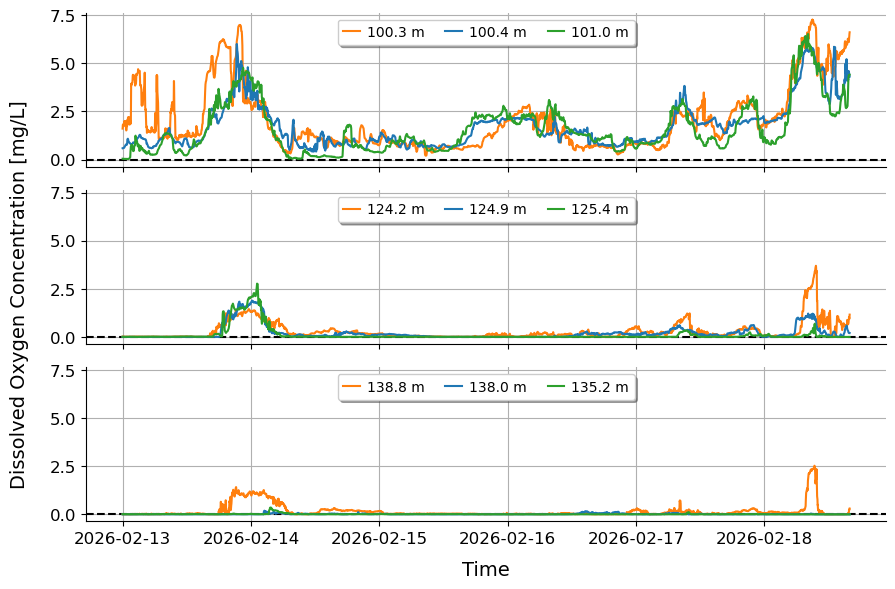

In [76]:
depths = [100, 125, 138]
t0 = '2026-02-13'

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(9, 6), sharex=True, sharey=True)

for i, d in enumerate(depths):
    # data selection
    ds_w = ds_do_w.sel(depth=d, method='nearest').sel(time=slice(t0, t_end))
    ds_c = ds_do_c.sel(depth=d, method='nearest').sel(time=slice(t0, t_end))
    ds_e = ds_do_e.sel(depth=d, method='nearest').sel(time=slice(t0, t_end))

    ax[i].axhline(0, color='black', linestyle='--')
    sns.lineplot(x=ds_w.time, y=ds_w.do2_conc, color='tab:orange', ax=ax[i], label=f'{ds_w.depth.item()} m')
    sns.lineplot(x=ds_c.time, y=ds_c.do2_conc, color='tab:blue', ax=ax[i], label=f'{ds_c.depth.item()} m')
    sns.lineplot(x=ds_e.time, y=ds_e.do2_conc, color='tab:green', ax=ax[i], label=f'{ds_e.depth.item()} m')

    ax[i].set_ylabel('')
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)

    ax[i].legend(ncols=3, fontsize=10, title_fontsize=10, shadow=True, loc='upper center', bbox_to_anchor=(0.5, 1),
                handlelength=1.2, handletextpad=0.5, columnspacing=1.5)

ax[2].set_xlabel('Time', fontsize=14, labelpad=10)
fig.supylabel('Dissolved Oxygen Concentration [mg/L]', fontsize=14, x=0.01)

plt.tight_layout()
plt.savefig('../gallery/zug_aphys_achem/2026_05_11/o2_signal_depth.svg', bbox_inches='tight')
plt.show()

### Flow speed

In [70]:
z_max = 130
z_min = 107

ds_c = ds_adcp_c.sel(time=slice(t0, t_end), depth=slice(z_max, z_min))
ds_w = ds_adcp_w.sel(time=slice(t0, t_end), depth=slice(z_max, z_min))
ds_e = ds_adcp_e.sel(time=slice(t0, t_end), depth=slice(z_max, z_min))

# shared time axis as mean of each instruments times
time_shared = np.mean([ds_c.time.values.astype('int64'),  ds_w.time.values.astype('int64'), ds_e.time.values.astype('int64')], axis=0).astype('datetime64[ns]')
ds_c = ds_c.assign_coords(time=time_shared)
ds_w = ds_w.assign_coords(time=time_shared)
ds_e = ds_e.assign_coords(time=time_shared)

In [71]:
# horizontal flow speed
uc = ds_c.vel.sel(dir='E')
vc = ds_c.vel.sel(dir='N')
speed_c = np.sqrt(uc**2 + vc**2).mean(dim='depth')

uw = ds_w.vel.sel(dir='E')
vw = ds_w.vel.sel(dir='N')
speed_w = np.sqrt(uw**2 + vw**2).mean(dim='depth')

ue = ds_e.vel.sel(dir='E')
ve = ds_e.vel.sel(dir='N')
speed_e = np.sqrt(ue**2 + ve**2).mean(dim='depth')

# 1-hour rolling average
window = 6
sc_ra = speed_c.rolling(time=window, center=True).mean()
sw_ra = speed_w.rolling(time=window, center=True).mean()
se_ra = speed_e.rolling(time=window, center=True).mean()

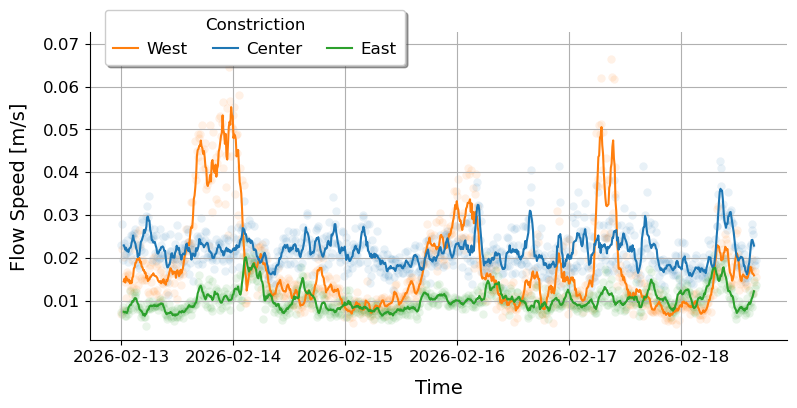

In [78]:
fig, ax = plt.subplots(figsize=(9, 4))

sns.scatterplot(x=speed_w.time, y=speed_w, alpha=0.1, color='tab:orange', ax=ax)
sns.scatterplot(x=speed_c.time, y=speed_c, alpha=0.1, color='tab:blue', ax=ax)
sns.scatterplot(x=speed_e.time, y=speed_e, alpha=0.1, color='tab:green', ax=ax)

sns.lineplot(x=sw_ra.time, y=sw_ra, label='West', color='tab:orange', ax=ax)
sns.lineplot(x=sc_ra.time, y=sc_ra, label='Center', color='tab:blue', ax=ax)
sns.lineplot(x=se_ra.time, y=se_ra, label='East', color='tab:green', ax=ax)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
ax.legend(ncols=3, title='Constriction', fontsize=12, title_fontsize=12, shadow=True, fancybox=True, loc='upper left', bbox_to_anchor=(0.01, 1.1),
          handlelength=1.5, handletextpad=0.5, columnspacing=1.5, borderpad=0.5)

plt.savefig('../gallery/zug_aphys_achem/2026_05_11/flow_speed.svg', bbox_inches='tight')
plt.show()

In [58]:
def plot_do_ts(ds_do_w, ds_do_c, ds_do_e, d, t0, tf):
    # data selection
    ds_w = ds_do_w.sel(depth=d, method='nearest').sel(time=slice(t0, tf))
    ds_c = ds_do_c.sel(depth=d, method='nearest').sel(time=slice(t0, tf))
    ds_e = ds_do_e.sel(depth=d, method='nearest').sel(time=slice(t0, tf))
    
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.axhline(0, color='black', linestyle='--')
    sns.lineplot(x=ds_w.time, y=ds_w.do2_conc, color='tab:orange', ax=ax, label=f'West | {ds_w.depth.item()}')
    sns.lineplot(x=ds_c.time, y=ds_c.do2_conc, color='tab:blue', ax=ax, label=f'Center | {ds_c.depth.item()}')
    sns.lineplot(x=ds_e.time, y=ds_e.do2_conc, color='tab:green', ax=ax, label=f'East | {ds_e.depth.item()}')

    ax.set_xlabel('Time', fontsize=14, labelpad=10)
    ax.set_ylabel('Dissolved Oxygen Concentration [mg/L]', fontsize=14, labelpad=10)
    ax.tick_params(axis='both', labelsize=12)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))

    #ax.set_ylim(0, None)
    ax.spines[['right', 'top']].set_visible(False)
    #ax.grid(True)

    ax.legend(ncols=3, title='Constriction | Depth [m]', fontsize=12, title_fontsize=12, shadow=True, loc='upper left', bbox_to_anchor=(0.01, 1.05),
                handlelength=1.2, handletextpad=0.5, columnspacing=1.5)

    plt.show()

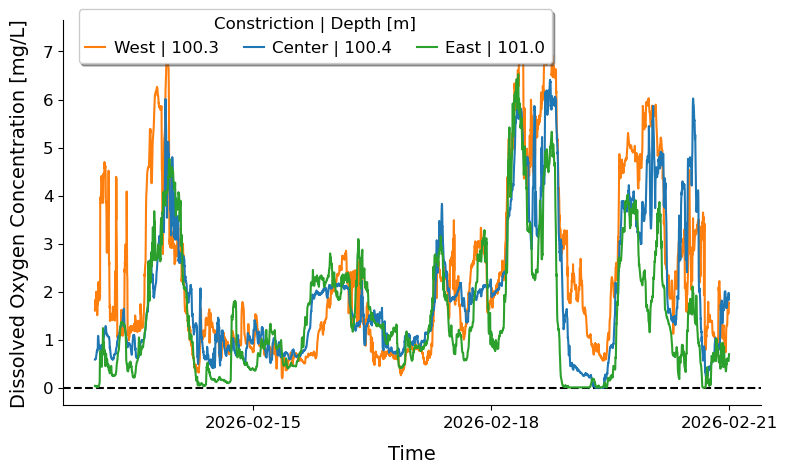

In [17]:
d = 100
t0 = '2026-02-13'
tf = '2026-02-20'

plot_do_ts(ds_do_w, ds_do_c, ds_do_e, d, t0, tf)

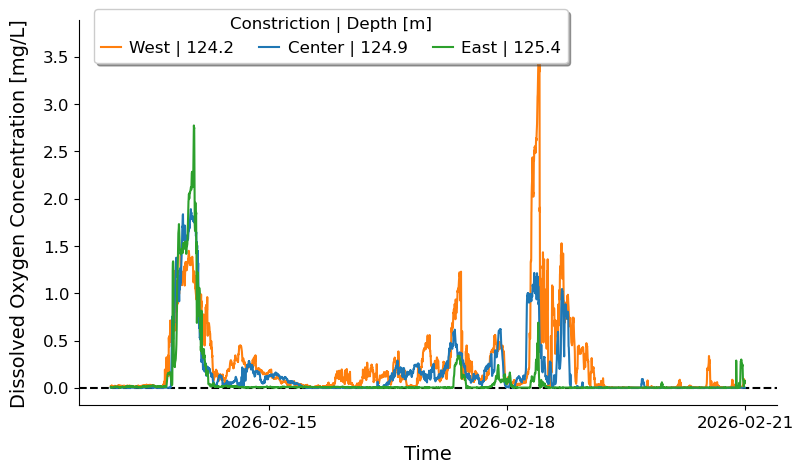

In [18]:
d = 125
t0 = '2026-02-13'
tf = '2026-02-20'

plot_do_ts(ds_do_w, ds_do_c, ds_do_e, d, t0, tf)

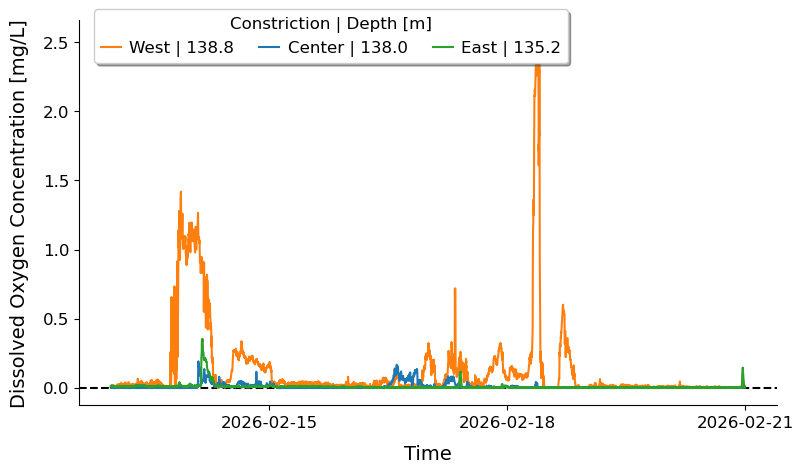

In [19]:
d = 140
t0 = '2026-02-13'
tf = '2026-02-20'

plot_do_ts(ds_do_w, ds_do_c, ds_do_e, d, t0, tf)

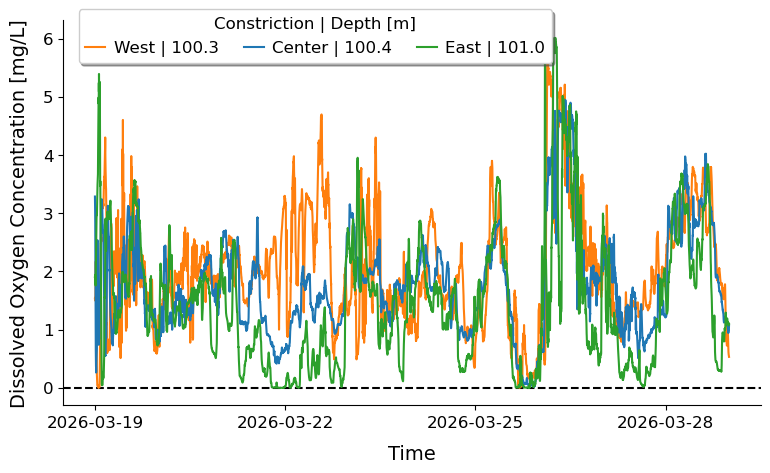

In [20]:
d = 100
t0 = '2026-03-19'
tf = '2026-03-28'

plot_do_ts(ds_do_w, ds_do_c, ds_do_e, d, t0, tf)

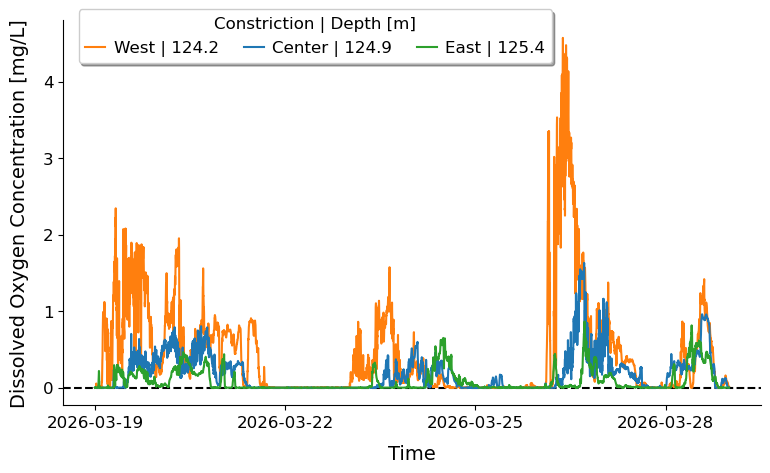

In [21]:
d = 125
t0 = '2026-03-19'
tf = '2026-03-28'

plot_do_ts(ds_do_w, ds_do_c, ds_do_e, d, t0, tf)

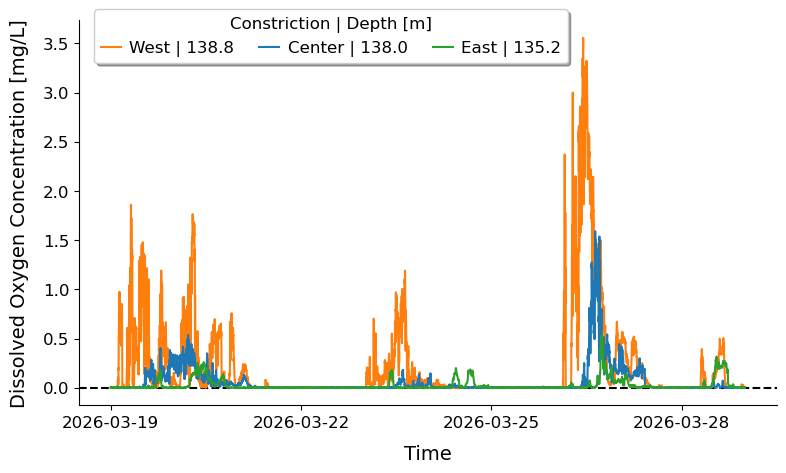

In [22]:
d = 140
t0 = '2026-03-19'
tf = '2026-03-28'

plot_do_ts(ds_do_w, ds_do_c, ds_do_e, d, t0, tf)

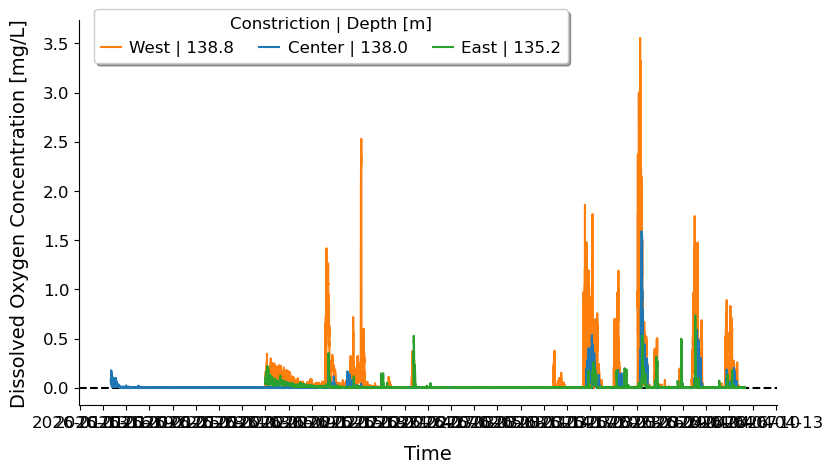

In [24]:
d = 140
t0 = None
tf = None

plot_do_ts(ds_do_w, ds_do_c, ds_do_e, d, t0, tf)